In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Must be set before importing abTEM/CuPy
import matplotlib.pyplot as plt
import abtem
import ase
import dask

In [2]:
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))

CUDA_VISIBLE_DEVICES = 0


In [3]:
import cupy as cp
print("CUDA_VISIBLE_DEVICES =", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("CuPy sees", cp.cuda.runtime.getDeviceCount(), "CUDA device(s)")
print("Current device:", cp.cuda.Device().id, cp.cuda.runtime.getDeviceProperties(0)["name"].decode())

CUDA_VISIBLE_DEVICES = 0
CuPy sees 1 CUDA device(s)
Current device: 0 NVIDIA A100 80GB PCIe


In [4]:
print(f"abtem.__version__ = {abtem.__version__}")

abtem.config.set({"device": "gpu"})
dask.config.set({"num_workers": 1})
abtem.config.set({"dask.chunk-size-gpu" : "1024 MB"})
abtem.config.set({"cupy.fft-cache-size" : "1024 MB"})

abtem.__version__ = 1.0.9


(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

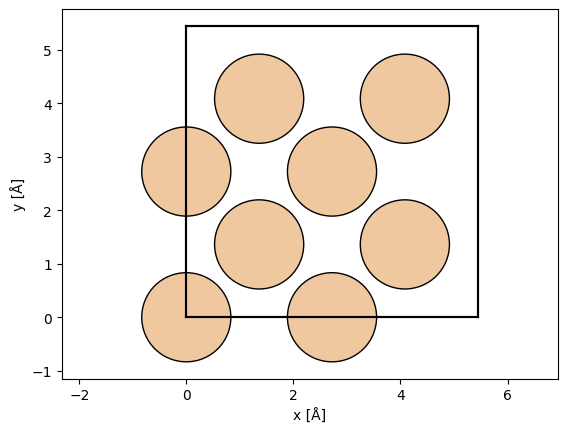

In [5]:
silicon = ase.io.read("Si.cif")

abtem.show_atoms(silicon, plane="xy")

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='x [Å]', ylabel='y [Å]'>)

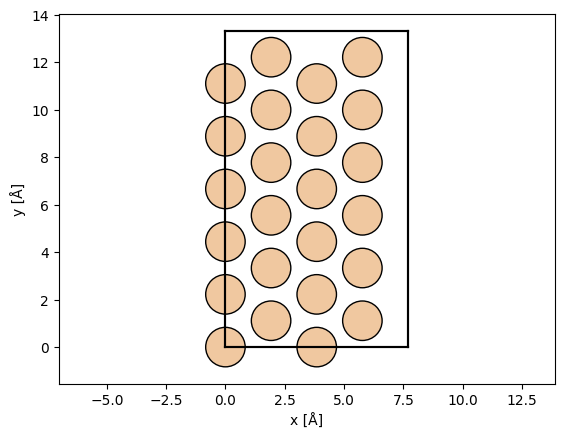

In [6]:
import numpy as np

silicon_111 = silicon.copy()
silicon_111.rotate((0,0,1), (1,1,1), rotate_cell=True)
silicon_111.rotate(45, 'z', rotate_cell=True)

silicon_111_orthogonal = abtem.orthogonalize_cell(silicon_111)  # make cell orthogonal

abtem.show_atoms(silicon_111_orthogonal)

Cell([92.38269265411871, 93.34005182655633, 1131.4522903347734])


(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Side view'}, xlabel='x [Å]', ylabel='z [Å]'>)

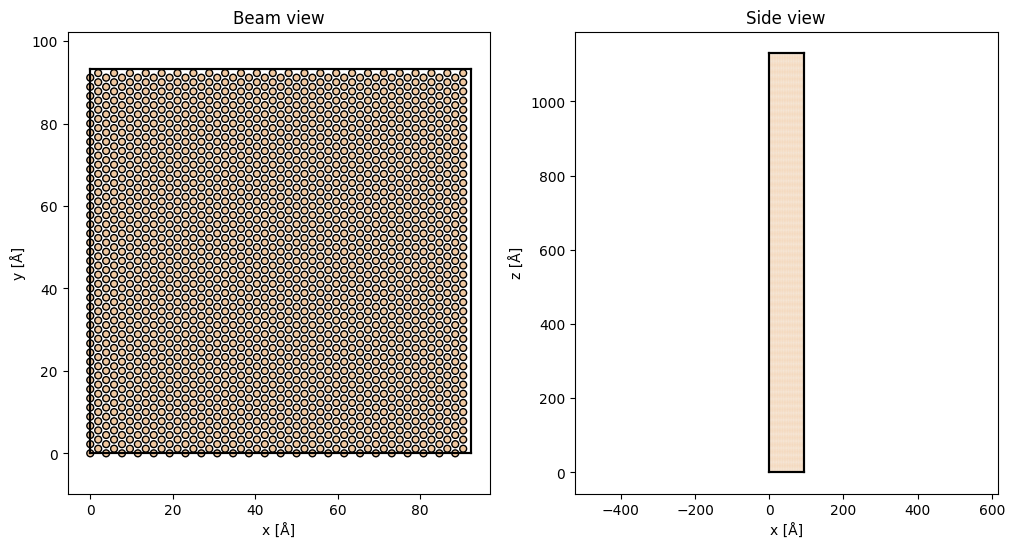

In [7]:
atoms = silicon_111_orthogonal * (12, 7, 120)
print(atoms.cell)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
abtem.show_atoms(atoms, ax=ax1, title="Beam view")
abtem.show_atoms(atoms, ax=ax2, plane="xz", title="Side view", linewidth=0.0)

In [8]:
slice_thicknesses = abtem.slicing.crystal_slice_thicknesses(atoms, tolerance=1e-2)
print(len(slice_thicknesses))

720


In [21]:
frozen_phonons = abtem.FrozenPhonons(atoms, 1, {"Si": 0.078})

In [22]:
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,
    projection="finite",
    slice_thickness=slice_thicknesses,
)

In [23]:
probe = abtem.Probe(energy=200e3, semiangle_cutoff=6.2)
probe.grid.match(potential)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

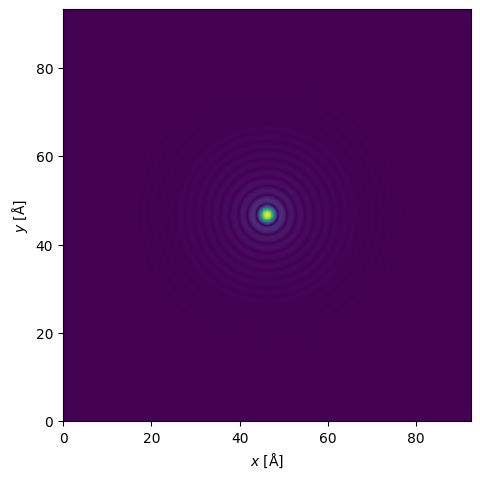

In [24]:

probe.show(power=0.5)

In [25]:
cbed = probe.multislice(potential=potential, max_batch=32).diffraction_patterns(max_angle='valid').mean(0)

In [26]:
cbed.axes_metadata

type                 label     coordinates
-------------------  --------  --------------------
ReciprocalSpaceAxis  kx [1/Å]  -2.36 -2.35 ... 2.36
ReciprocalSpaceAxis  ky [1/Å]  -2.36 -2.35 ... 2.36

In [27]:
cbed.compute()

tasks:   0%|          | 0/6 [00:00<?, ?it/s]

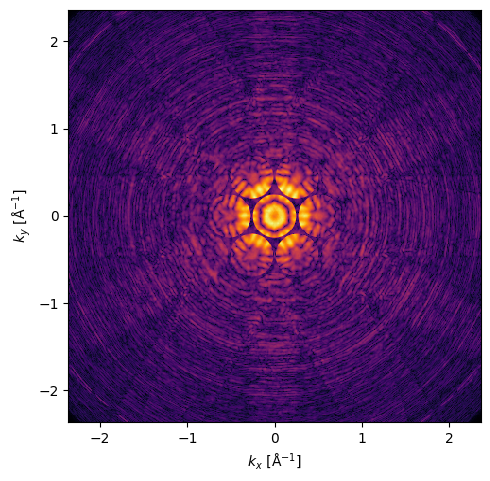

In [28]:
cbed.show(power=0.25, cmap='inferno')